### Setup

In [18]:
import numpy as np
import matplotlib.pyplot as plt

### Gauss-Jordan

In [19]:
def resolver_gauss_jordan(A, b):
    A = A.astype(float)
    b = b.astype(float).reshape(-1, 1)
    n = len(b)
    
    # Cria a matriz aumentada [A | b]
    Ab = np.hstack([A, b])
    
    for i in range(n):
        # Pivoteamento parcial: encontra o maior valor absoluto na coluna
        max_row = np.argmax(np.abs(Ab[i:n, i])) + i
        if i != max_row:
            # Troca as linhas
            Ab[[i, max_row]] = Ab[[max_row, i]]
            
        if Ab[i, i] == 0:
            raise ValueError("As colunas da matriz B não são linearmente independentes.")
            
        # Divide a linha atual pelo valor do pivô (para que o pivô vire 1)
        Ab[i] = Ab[i] / Ab[i, i]
        
        # Zera todos os outros elementos da coluna i (acima e abaixo do pivô)
        for j in range(n):
            if i != j:
                Ab[j] = Ab[j] - Ab[j, i] * Ab[i]
                
    # Retorna a última coluna, que agora contém a solução do sistema
    return Ab[:, -1]

### Projeção Ortogonal

In [20]:
def projecao_ortogonal(x, B):
    """
    Calcula a melhor aproximação (projeção ortogonal) do sinal x 
    no subespaço gerado pelas colunas da matriz base B.
    
    Args:
        x (np.ndarray): Sinal original, array de dimensão (n,)
        B (np.ndarray): Matriz base, array de dimensão (n, k)
        
    Returns:
        x_til (np.ndarray): O sinal aproximado em R^n
        x_coords (np.ndarray): As coordenadas [x_til]_B em R^k
    """
    B_T = B.T
    
    # (B^T B) e (B^T x)
    BtB = B_T @ B
    Btx = B_T @ x
    
    # Coordenadas da aproximação [x_til]_B
    # Resolve (B^T B) * coords = B^T x
    x_coords = resolver_gauss_jordan(BtB, Btx)
    
    # Sinal projetado no espaço original
    # x_til = B * [x_til]_B
    x_til = B @ x_coords
    
    return x_til, x_coords

### Criandos casos de teste

In [21]:
casos_de_teste = [
    {
        "descricao": "Projeção de um vetor 3D no plano XY (zela o eixo Z)",
        "x": np.array([3, 4, 5]),
        "B": np.array([
            [1, 0], 
            [0, 1], 
            [0, 0]
        ])
    },
    {
        "descricao": "O vetor já pertence ao subespaço (não deve sofrer alteração)",
        "x": np.array([7, -2, 0]),
        "B": np.array([
            [1, 0], 
            [0, 1], 
            [0, 0]
        ])
    },
    {
        "descricao": "Projeção de um vetor 2D sobre uma reta (Eixo X)",
        "x": np.array([5, 8]),
        "B": np.array([
            [1], 
            [0]
        ])
    },
    {
        "descricao": "Projeção em um subespaço com base arbitrária no R^3",
        "x": np.array([1, 2, 3]),
        "B": np.array([
            [1, 1], 
            [0, 1], 
            [1, 0]
        ])
    }
]

### Execução do Teste

In [22]:
for i, caso in enumerate(casos_de_teste, start=1):
    x = caso["x"]
    B = caso["B"]
    descricao = caso["descricao"]
    
    print(f"=========================================")
    print(f"TESTE {i}: {descricao}")
    print(f"=========================================")
    print(f"Sinal original (x): {x}")
    print(f"Matriz Base (B):\n{B}\n")
    
    try:
        sinal_aproximado, coordenadas = projecao_ortogonal(x, B)
        

        erro = x - sinal_aproximado
        produto_interno = B.T @ erro
        is_ortogonal = np.allclose(produto_interno, 0)
        coordenadas_print = np.round(coordenadas, 4)
        sinal_aproximado_print = np.round(sinal_aproximado, 4)
        erro_print = np.round(erro, 4)
        
        print(f"-> Coordenadas da aproximação [x_til]_B: {coordenadas_print}")
        print(f"-> Sinal projetado no espaço original (x_til): {sinal_aproximado_print}")
        print(f"-> Vetor de Erro (e): {erro_print}")
        print(f"-> B^T * e: {np.round(produto_interno, 10)}")
        
        if is_ortogonal:
            print("-> STATUS DE ORTOGONALIDADE: SUCESSO (O erro é ortogonal ao subespaço)")
        else:
            print("-> STATUS DE ORTOGONALIDADE: FALHA (O erro não é ortogonal)")
            
    except ValueError as e:
        print(f"-> ERRO DE VALIDAÇÃO: {e}")
        
    print("\n")

TESTE 1: Projeção de um vetor 3D no plano XY (zela o eixo Z)
Sinal original (x): [3 4 5]
Matriz Base (B):
[[1 0]
 [0 1]
 [0 0]]

-> Coordenadas da aproximação [x_til]_B: [3. 4.]
-> Sinal projetado no espaço original (x_til): [3. 4. 0.]
-> Vetor de Erro (e): [0. 0. 5.]
-> B^T * e: [0. 0.]
-> STATUS DE ORTOGONALIDADE: SUCESSO (O erro é ortogonal ao subespaço)


TESTE 2: O vetor já pertence ao subespaço (não deve sofrer alteração)
Sinal original (x): [ 7 -2  0]
Matriz Base (B):
[[1 0]
 [0 1]
 [0 0]]

-> Coordenadas da aproximação [x_til]_B: [ 7. -2.]
-> Sinal projetado no espaço original (x_til): [ 7. -2.  0.]
-> Vetor de Erro (e): [0. 0. 0.]
-> B^T * e: [0. 0.]
-> STATUS DE ORTOGONALIDADE: SUCESSO (O erro é ortogonal ao subespaço)


TESTE 3: Projeção de um vetor 2D sobre uma reta (Eixo X)
Sinal original (x): [5 8]
Matriz Base (B):
[[1]
 [0]]

-> Coordenadas da aproximação [x_til]_B: [5.]
-> Sinal projetado no espaço original (x_til): [5. 0.]
-> Vetor de Erro (e): [0. 8.]
-> B^T * e: [0.]

### Visualização Gráfica

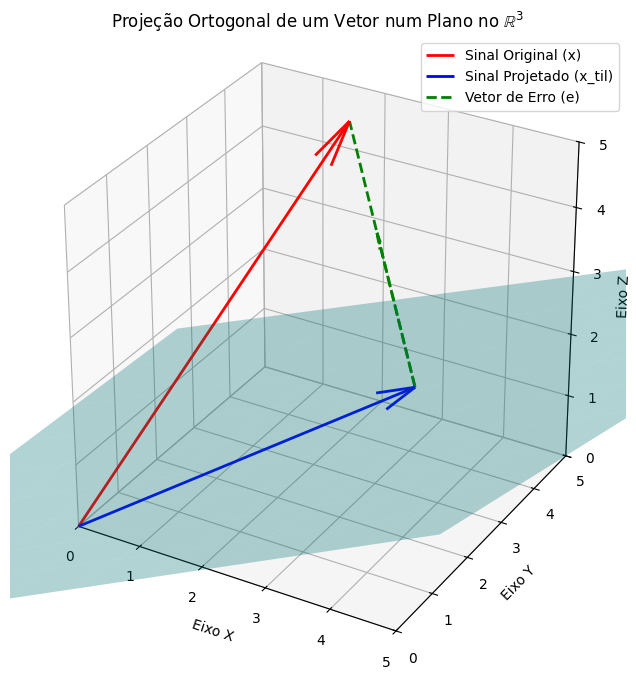

In [23]:
x = np.array([2, 4, 5]) 
B = np.array([
    [1, 1],
    [1, 0],
    [0, 1]
])
x_til, coordenadas = projecao_ortogonal(x, B)

fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')
grid_s, grid_t = np.meshgrid(np.linspace(-2, 5, 10), np.linspace(-2, 5, 10))
X_plano = grid_s * B[0, 0] + grid_t * B[0, 1]
Y_plano = grid_s * B[1, 0] + grid_t * B[1, 1]
Z_plano = grid_s * B[2, 0] + grid_t * B[2, 1]

ax.plot_surface(X_plano, Y_plano, Z_plano, alpha=0.3, color='c', edgecolor='none')

origem = np.array([0, 0, 0])
ax.quiver(*origem, *x, color='red', arrow_length_ratio=0.1, label='Sinal Original (x)', linewidth=2)
ax.quiver(*origem, *x_til, color='blue', arrow_length_ratio=0.1, label='Sinal Projetado (x_til)', linewidth=2)
ax.quiver(*x_til, *erro, color='green', linestyle='dashed', arrow_length_ratio=0.1, label='Vetor de Erro (e)', linewidth=2)

ax.set_xlim([0, 5])
ax.set_ylim([0, 5])
ax.set_zlim([0, 5])
ax.set_xlabel('Eixo X')
ax.set_ylabel('Eixo Y')
ax.set_zlabel('Eixo Z')
ax.set_title(r'Projeção Ortogonal de um Vetor num Plano no $\mathbb{R}^3$')
ax.legend()

ax.plot(
    [x_til[0], x[0]], 
    [x_til[1], x[1]], 
    [x_til[2], x[2]], 
    color='green', 
    linestyle='dashed', 
    label='Vetor de Erro (e)', 
    linewidth=2
)

ax.set_box_aspect([1, 1, 1])

plt.show()